In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated
from dotenv import load_dotenv

In [3]:
# crete a model
load_dotenv()
# create an LLM model
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv('GROQ_API_KEY'),
    temperature=0
)

c:\Users\Ansh\OneDrive\Desktop\Langraph\meraenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from pydantic import BaseModel, Field


class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay. Do NOT include the score in this text.")
    score: int = Field(description="Numerical score out of 10 for the essay (integer only, no text)", ge=0, le=10)


In [5]:
structured_model =llm.with_structured_output(EvaluationSchema)

In [6]:
import operator


class Upsc(TypedDict):
    essay:str
    f1:str
    f2:str
    f3:str
    score:Annotated[list[int],operator.add]
    summary:str
    avg:float


In [7]:
def cot(state:Upsc)->Upsc:
    prompt = f"Generate clarity of thoughts for this essay and give score out of 10:{state['essay']} "
    feedback = structured_model.invoke(prompt).feedback
    score = structured_model.invoke(prompt).score
    return {'f1': feedback, 'score': [score]}


In [8]:
def doa(state:Upsc)->Upsc:
    prompt = f"Generate depth of analysis for this essay and give score out of 10:{state['essay']} "
    feedback = structured_model.invoke(prompt).feedback  # we are not using llm.invoke() here we are using stcutred output model..
    score = structured_model.invoke(prompt).score
    return {'f2': feedback, 'score': [score]}


In [9]:
def lang(state:Upsc)->Upsc:
    prompt = f"Generate language proficiency like grammar, vocabulary, flow and other parameters for this essay and give score out of 10:{state['essay']} "
    feedback = structured_model.invoke(prompt).feedback
    score = structured_model.invoke(prompt).score
    return {'f3': feedback, 'score': [score]}


In [13]:
def final_eval(state:Upsc)->Upsc:
    prompt = f"Based on these three feedbacks generate a combined feedback \n Language feedback: {state['f3']}\nClarity of thoughts feedback: {state['f1']} \n Depth of analysis feedback: {state['f2']}"
    #   Also generate average score from these three scores: {state['score']}"
    summary = llm.invoke(prompt).content    
    avg = sum(state['score'])/3    # state['score'] this is a list of 3 scores
    return {'summary':summary,'avg':avg}


In [14]:
graph=StateGraph(Upsc)

graph.add_node('cot',cot)
graph.add_node('doa',doa)
graph.add_node('lang',lang)

graph.add_node('final',final_eval)

graph.add_edge(START,'cot')
graph.add_edge(START,'doa')
graph.add_edge(START,'lang')

graph.add_edge('cot','final')
graph.add_edge('doa','final')
graph.add_edge('lang','final')



workflow = graph.compile()

final_state = workflow.invoke({'essay':"automobiles have greatly influenced modern society by providing unprecedented mobility and convenience. They have transformed the way people live, work, and interact, enabling individuals to commute longer distances for employment and leisure. The automobile industry has also been a significant driver of economic growth, creating millions of jobs and fostering technological advancements. However, the widespread use of automobiles has also led to environmental challenges, such as air pollution and climate change, prompting a shift towards more sustainable transportation options like electric vehicles and public transit systems. Overall, automobiles continue to play a crucial role in shaping contemporary life while also necessitating considerations for environmental impact and urban planning."})

print(final_state)

{'essay': 'automobiles have greatly influenced modern society by providing unprecedented mobility and convenience. They have transformed the way people live, work, and interact, enabling individuals to commute longer distances for employment and leisure. The automobile industry has also been a significant driver of economic growth, creating millions of jobs and fostering technological advancements. However, the widespread use of automobiles has also led to environmental challenges, such as air pollution and climate change, prompting a shift towards more sustainable transportation options like electric vehicles and public transit systems. Overall, automobiles continue to play a crucial role in shaping contemporary life while also necessitating considerations for environmental impact and urban planning.', 'f1': 'The essay provides a clear and well-structured argument on the impact of automobiles on modern society. It effectively explores both the benefits and drawbacks of automobile use,

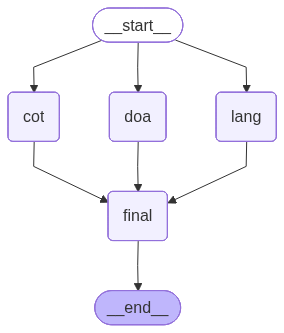

In [15]:
graph.compile()

In [16]:
from pprint import pprint
pprint(final_state, width=100, depth=None, compact=False)

{'avg': 8.0,
 'essay': 'automobiles have greatly influenced modern society by providing unprecedented mobility '
          'and convenience. They have transformed the way people live, work, and interact, '
          'enabling individuals to commute longer distances for employment and leisure. The '
          'automobile industry has also been a significant driver of economic growth, creating '
          'millions of jobs and fostering technological advancements. However, the widespread use '
          'of automobiles has also led to environmental challenges, such as air pollution and '
          'climate change, prompting a shift towards more sustainable transportation options like '
          'electric vehicles and public transit systems. Overall, automobiles continue to play a '
          'crucial role in shaping contemporary life while also necessitating considerations for '
          'environmental impact and urban planning.',
 'f1': 'The essay provides a clear and well-structured 

In [ ]:
structured_model.invoke("honda cars are very relaibale")   #only 2 tings are there in llm output no metadata and all is present

EvaluationSchema(feedback='Honda cars are known for their reliability, durability, and low maintenance costs. They have a reputation for being long-lasting and requiring less frequent repairs compared to other brands.', score=8)

In [12]:
structured_model.invoke("honda cars are very relaibale").feedback

'Honda cars are known for their reliability, durability, and low maintenance costs. They have a reputation for being long-lasting and requiring less frequent repairs compared to other brands.'

In [17]:
structured_model.invoke("honda cars are very relaibale").score

8